# Exploratory Data Analysis (EDA)
## Flight Delays and Cancellations — Miami International Airport (MIA)

The dataset contains 19,396 flights departing from Miami International Airport (MIA)
between January 1 and February 29, 2024.

NOTE: Data covers only the first two months of 2024 (winter season).
Insights reflect winter operational patterns and may not generalize to the full year.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

df = pd.read_csv("../data/processed/mia_flights_clean.csv")
df['fl_date'] = pd.to_datetime(df['fl_date'])
df['dep_hour'] = pd.to_numeric(df['dep_time'], errors='coerce') // 100

print(f"Shape: {df.shape}")
print(f"Date range: {df['fl_date'].min().date()} to {df['fl_date'].max().date()}")
df.head()


Shape: (19396, 19)
Date range: 2024-01-01 to 2024-02-29


,year,month,day_of_month,day_of_week,fl_date,origin,origin_city_name,origin_state_nm,dep_time,taxi_out,wheels_off,wheels_on,taxi_in,cancelled,air_time,distance,weather_delay,late_aircraft_delay,dep_hour
0,2024,1,1,1,2024-01-01,MIA,"Miami, FL",Florida,1758.0,34.0,1832.0,2012.0,7.0,0,100.0,700,0,0,17.0
1,2024,1,1,1,2024-01-01,MIA,"Miami, FL",Florida,2042.0,16.0,2058.0,2227.0,6.0,0,89.0,594,0,87,20.0
2,2024,1,1,1,2024-01-01,MIA,"Miami, FL",Florida,840.0,20.0,900.0,1030.0,10.0,0,90.0,594,0,0,8.0
3,2024,1,1,1,2024-01-01,MIA,"Miami, FL",Florida,2111.0,17.0,2128.0,12.0,6.0,0,164.0,1258,0,0,21.0
4,2024,1,1,1,2024-01-01,MIA,"Miami, FL",Florida,2159.0,28.0,2227.0,7.0,6.0,0,100.0,650,0,0,21.0


## 1. Dataset Overview

Basic descriptive statistics and contextual information about the dataset.


In [2]:
print(f"Total flights: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

Total flights: 19,396
Columns: 19


In [3]:
print(f"Start date: {df['fl_date'].min().date()}")
print(f"End date:   {df['fl_date'].max().date()}")
print("Coverage: January–February 2024 (winter season only)")


Start date: 2024-01-01
End date:   2024-02-29
Coverage: January–February 2024 (winter season only)


In [4]:
df.describe()

,year,month,day_of_month,day_of_week,fl_date,dep_time,taxi_out,wheels_off,wheels_on,taxi_in,cancelled,air_time,distance,weather_delay,late_aircraft_delay,dep_hour
count,19396.0,19396.000000,19396.000000,19396.000000,19396,19216.000000,19191.000000,19191.000000,19186.000000,19186.000000,19396.000000,19129.000000,19396.000000,19396.000000,19396.000000,19216.000000
mean,2024.0,1.477006,15.265312,3.947927,2024-01-30 01:15:34.708187,1479.025916,22.174874,1508.609035,1530.826697,8.476858,0.010724,151.093889,1078.597649,0.772737,8.007115,14.490373
min,2024.0,1.000000,1.000000,1.000000,2024-01-01 00:00:00,1.000000,3.000000,1.000000,1.000000,1.000000,0.000000,25.000000,126.000000,0.000000,0.000000,0.000000
25%,2024.0,1.000000,8.000000,2.000000,2024-01-15 00:00:00,1000.000000,15.000000,1017.000000,1107.000000,5.000000,0.000000,110.000000,710.000000,0.000000,0.000000,10.000000
50%,2024.0,1.000000,15.000000,4.000000,2024-01-30 00:00:00,1538.000000,19.000000,1554.000000,1635.000000,7.000000,0.000000,141.000000,1085.000000,0.000000,0.000000,15.000000
75%,2024.0,2.000000,23.000000,6.000000,2024-02-14 00:00:00,1935.000000,26.000000,1957.000000,2046.000000,10.000000,0.000000,167.000000,1194.000000,0.000000,0.000000,19.000000
max,2024.0,2.000000,31.000000,7.000000,2024-02-29 00:00:00,2400.000000,166.000000,2400.000000,2400.000000,145.000000,1.000000,416.000000,2724.000000,952.000000,1541.000000,24.000000
std,0.0,0.499484,8.598125,2.008867,NaN,522.807114,11.266938,528.124791,638.114480,6.272810,0.103002,73.825119,545.511130,16.564295,40.020318,5.240310


## 2. Cancellation Analysis

We analyze cancellation rates overall and across time dimensions.
NOTE: Cancellation rate is only 1.07% — highly imbalanced.
This is why modeling shifted to delay prediction instead.


In [5]:
cancellation_rate = df['cancelled'].mean()
print(f"Overall cancellation rate: {cancellation_rate:.2%}")
print(f"Total cancellations: {df['cancelled'].sum():,} out of {len(df):,} flights")


Overall cancellation rate: 1.07%
Total cancellations: 208 out of 19,396 flights


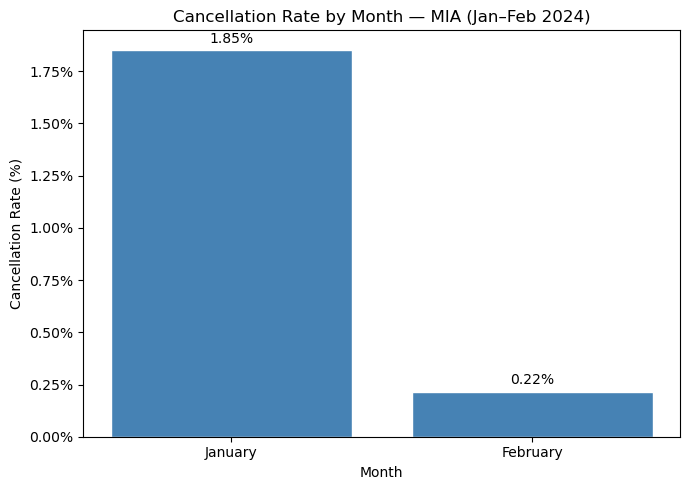

In [6]:
monthly_cancellation = df.groupby('month')['cancelled'].mean() * 100

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(
    ['January', 'February'],
    monthly_cancellation.values,
    color=['steelblue', 'steelblue'],
    edgecolor='white'
)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=2))
ax.set_xlabel("Month")
ax.set_ylabel("Cancellation Rate (%)")
ax.set_title("Cancellation Rate by Month — MIA (Jan–Feb 2024)")
ax.bar_label(bars, fmt='%.2f%%', padding=3, fontsize=10)
plt.tight_layout()
plt.savefig("../outputs/cancellation_by_month.png", dpi=150)
plt.show()



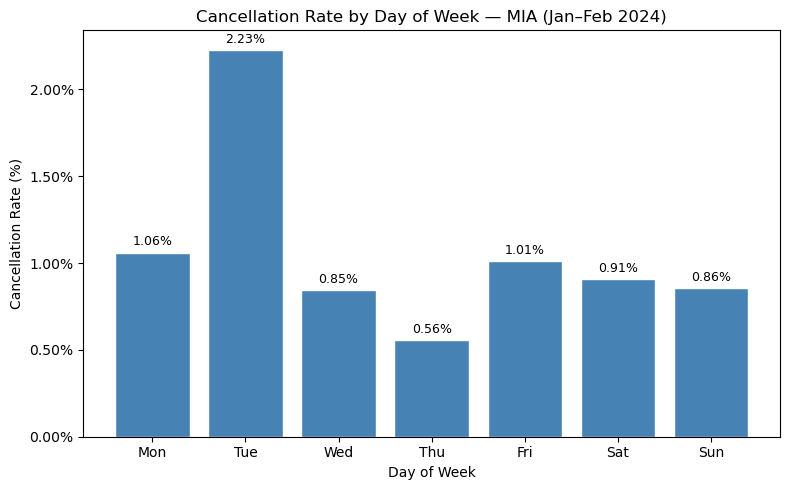


Key finding: Tuesday shows the highest cancellation rate.


In [7]:
dow_labels = {1: 'Mon', 2: 'Tue', 3: 'Wed', 4: 'Thu', 5: 'Fri', 6: 'Sat', 7: 'Sun'}
dow_cancellation = df.groupby('day_of_week')['cancelled'].mean() * 100
dow_cancellation.index = dow_cancellation.index.map(dow_labels)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(
    dow_cancellation.index,
    dow_cancellation.values,
    color='steelblue',
    edgecolor='white'
)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=2))
ax.set_xlabel("Day of Week")
ax.set_ylabel("Cancellation Rate (%)")
ax.set_title("Cancellation Rate by Day of Week — MIA (Jan–Feb 2024)")
ax.bar_label(bars, fmt='%.2f%%', padding=3, fontsize=9)
plt.tight_layout()
plt.savefig("../outputs/cancellation_by_dow.png", dpi=150)
plt.show()

print("\nKey finding: Tuesday shows the highest cancellation rate.")


## 3. Delay Analysis

We examine the two primary delay types available in the dataset:
- Weather Delay: caused by meteorological conditions
- Late Aircraft Delay: caused by previous flight arriving late (cascading effect)


In [8]:
print("Average delay (all flights, including zeros):")
print(df[['weather_delay', 'late_aircraft_delay']].mean().round(2))

print("\nAmong delayed flights only:")
print(df[df['weather_delay'] > 0]['weather_delay'].mean().round(2), "min avg weather delay")
print(df[df['late_aircraft_delay'] > 0]['late_aircraft_delay'].mean().round(2), "min avg late aircraft delay")


Average delay (all flights, including zeros):
weather_delay          0.77
late_aircraft_delay    8.01
dtype: float64

Among delayed flights only:
69.71 min avg weather delay
52.75 min avg late aircraft delay


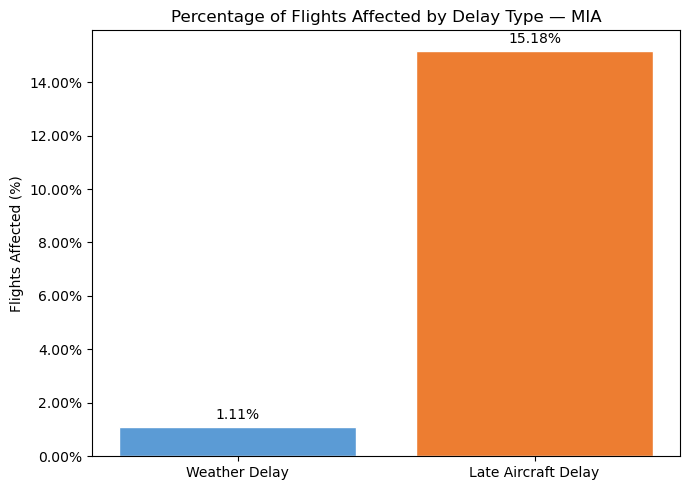

Weather delay:      1.11% of flights
Late aircraft delay: 15.18% of flights


In [9]:
weather_pct = (df['weather_delay'] > 0).mean() * 100
late_pct = (df['late_aircraft_delay'] > 0).mean() * 100

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(
    ['Weather Delay', 'Late Aircraft Delay'],
    [weather_pct, late_pct],
    color=['#5B9BD5', '#ED7D31'],
    edgecolor='white'
)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=2))
ax.set_ylabel("Flights Affected (%)")
ax.set_title("Percentage of Flights Affected by Delay Type — MIA")
ax.bar_label(bars, fmt='%.2f%%', padding=3, fontsize=10)
plt.tight_layout()
plt.savefig("../outputs/delay_type_pct.png", dpi=150)
plt.show()

print(f"Weather delay:      {weather_pct:.2f}% of flights")
print(f"Late aircraft delay: {late_pct:.2f}% of flights")


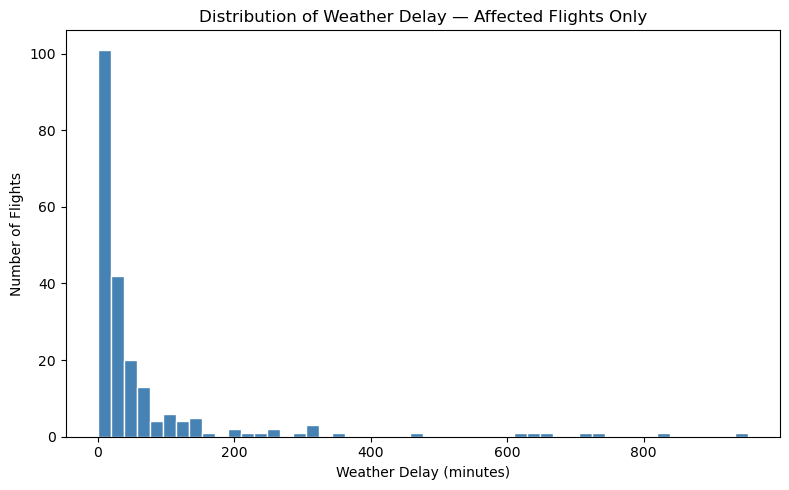

In [10]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(df[df['weather_delay'] > 0]['weather_delay'], bins=50,
        color='steelblue', edgecolor='white')
ax.set_xlabel("Weather Delay (minutes)")
ax.set_ylabel("Number of Flights")
ax.set_title("Distribution of Weather Delay — Affected Flights Only")
plt.tight_layout()
plt.savefig("../outputs/weather_delay_distribution.png", dpi=150)
plt.show()


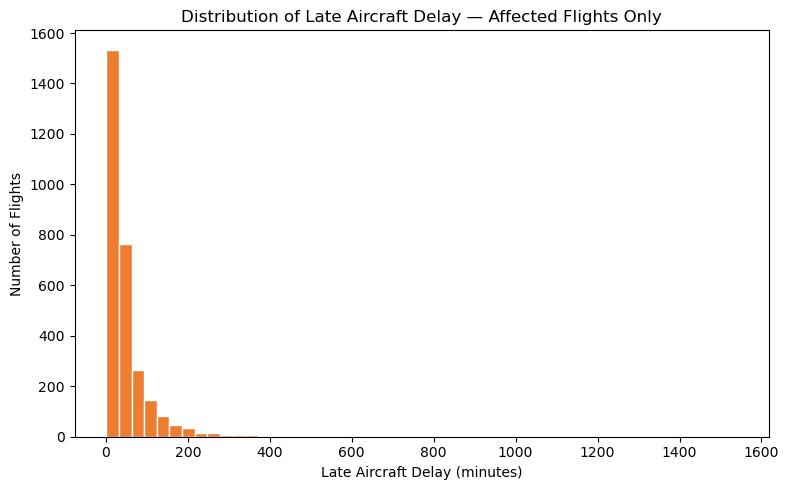

In [11]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(df[df['late_aircraft_delay'] > 0]['late_aircraft_delay'], bins=50,
        color='#ED7D31', edgecolor='white')
ax.set_xlabel("Late Aircraft Delay (minutes)")
ax.set_ylabel("Number of Flights")
ax.set_title("Distribution of Late Aircraft Delay — Affected Flights Only")
plt.tight_layout()
plt.savefig("../outputs/late_aircraft_delay_distribution.png", dpi=150)
plt.show()


## 4. Time-of-Day Risk Patterns

We analyze whether departure time influences cancellation and delay likelihood.
Flights departing later in the day may accumulate operational disruptions
from earlier flights (cascading delay effect).

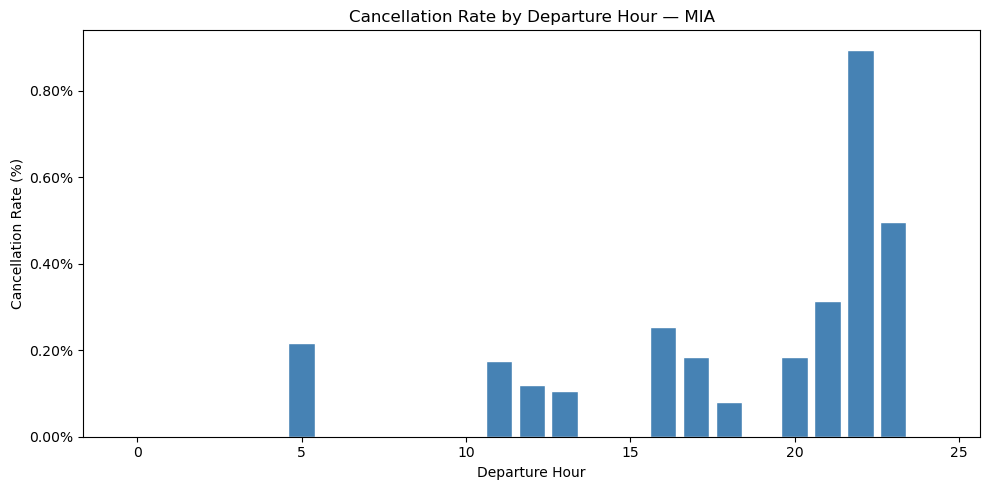

In [12]:
hourly_cancel = df.groupby('dep_hour')['cancelled'].mean() * 100

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(hourly_cancel.index, hourly_cancel.values,
       color='steelblue', edgecolor='white')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=2))
ax.set_xlabel("Departure Hour")
ax.set_ylabel("Cancellation Rate (%)")
ax.set_title("Cancellation Rate by Departure Hour — MIA")
plt.tight_layout()
plt.savefig("../outputs/cancellation_rate_by_departure_hour.png", dpi=150)
plt.show()

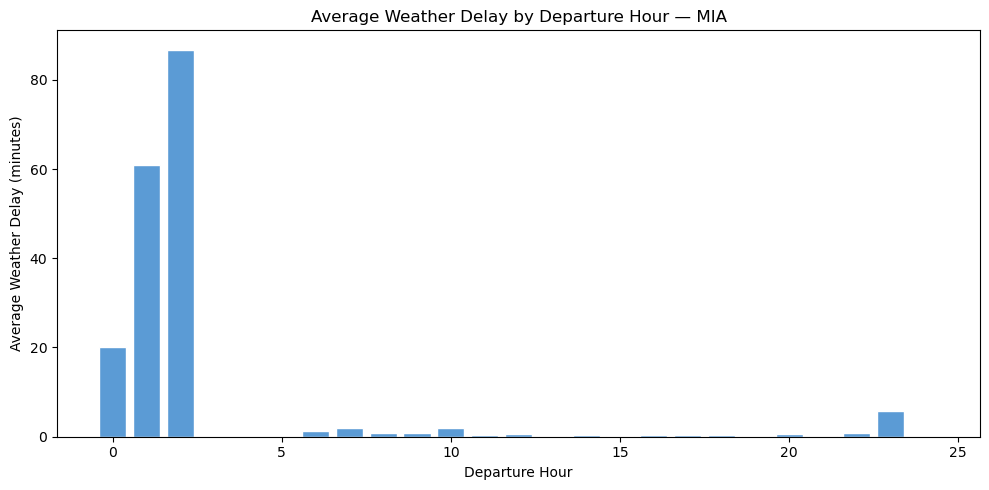

In [13]:
hourly_weather = df.groupby('dep_hour')['weather_delay'].mean()

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(hourly_weather.index, hourly_weather.values,
       color='#5B9BD5', edgecolor='white')
ax.set_xlabel("Departure Hour")
ax.set_ylabel("Average Weather Delay (minutes)")
ax.set_title("Average Weather Delay by Departure Hour — MIA")
plt.tight_layout()
plt.savefig("../outputs/weather_delay_by_hour.png", dpi=150)
plt.show()

## 5. Distance and Delay Relationship

We analyze whether flight distance is associated with greater delays.


In [14]:
corr = df[['distance', 'weather_delay', 'late_aircraft_delay']].corr()
print("Correlation matrix:")
print(corr.round(4))
print("\nKey finding: Distance shows near-zero correlation with both delay types.")
print("Delays are operationally driven, not distance-driven.")


Correlation matrix:
                     distance  weather_delay  late_aircraft_delay
distance               1.0000         0.0206              -0.0087
weather_delay          0.0206         1.0000               0.0370
late_aircraft_delay   -0.0087         0.0370               1.0000

Key finding: Distance shows near-zero correlation with both delay types.
Delays are operationally driven, not distance-driven.


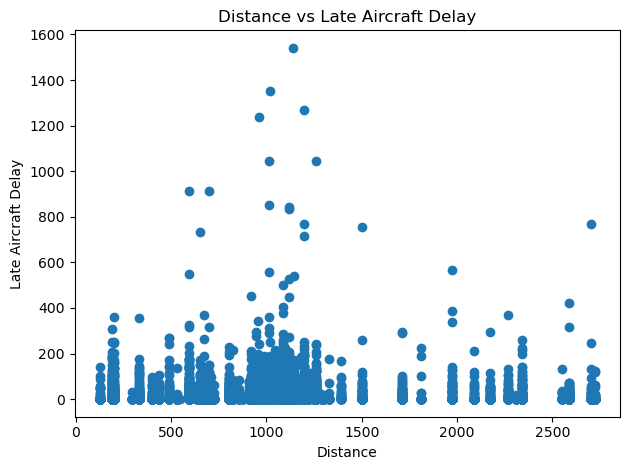

In [13]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(df['distance'], df['late_aircraft_delay'],
           alpha=0.3, s=8, color='steelblue')
ax.set_xlabel("Distance (miles)")
ax.set_ylabel("Late Aircraft Delay (minutes)")
ax.set_title("Distance vs Late Aircraft Delay — MIA")
plt.tight_layout()
plt.savefig("../outputs/distance_vs_late_aircraft_delay.png", dpi=150)
plt.show()



## 6. Outlier Analysis

We identify extreme values in delay variables using the IQR method.

In [15]:
Q1 = df['weather_delay'].quantile(0.25)
Q3 = df['weather_delay'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR

outliers = df[df['weather_delay'] > upper_bound]
print(f"Weather delay outliers: {len(outliers):,} ({len(outliers)/len(df):.2%} of flights)")
print(f"Upper bound (IQR method): {upper_bound:.1f} minutes")
print(f"Max weather delay: {df['weather_delay'].max():.0f} minutes")


Weather delay outliers: 215 (1.11% of flights)
Upper bound (IQR method): 0.0 minutes
Max weather delay: 952 minutes


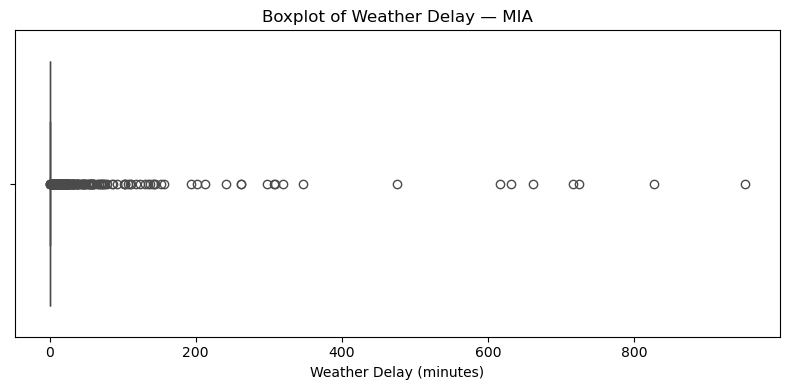

In [16]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.boxplot(x=df['weather_delay'], color='steelblue', ax=ax)
ax.set_xlabel("Weather Delay (minutes)")
ax.set_title("Boxplot of Weather Delay — MIA")
plt.tight_layout()
plt.savefig("../outputs/weather_delay_boxplot.png", dpi=150)
plt.show()



## 7. Key Insights

1. Overall cancellation rate at MIA (Jan–Feb 2024): 1.07% — extremely low.
   This imbalance makes cancellation prediction unreliable as a modeling target.

2. Tuesday shows the highest cancellation rate (2.23%), nearly double the average.

3. Late aircraft delay affects 15.18% of flights vs 1.11% for weather delay.
   Operational ripple effects (cascading delays) are more prevalent than weather.

4. Flights departing later in the day show higher disruption risk,
   consistent with cumulative delay propagation throughout the day.

5. Distance has near-zero correlation with delays (r ≈ 0.02).
   Delays are operationally driven, not distance-driven.

6. Delay distributions are highly right-skewed with extreme outliers
   (max weather delay: 952 minutes, max late aircraft: 1,541 minutes).

These findings motivated reframing the modeling objective from
cancellation prediction to delay prediction (>15 minutes).
